# **06. Cluster Experiment --- Ames Housing Dataset**

## **Introduction**

I'll use the __CRISP-DM process__ to explore the Ames Housing dataset and answer three common questions about housing markets. The dataset comes from the Kaggle competition House Prices - Advanced Regression Techniques, where the challenge is to predict home prices in Ames, Iowa using 79 features. With over 20,000 submissions, it’s a well-studied dataset and a great way to practice and showcase machine learning skills.

### **Objectives**

I'll use the __CRISP-DM process__ with the Ames Housing dataset to explore three key questions about the housing market.

__1. What are the typical house price ranges in the Ames dataset?__

**Identify the main price ranges in the dataset**. Knowing which ranges most houses fall into and how prices are spread out will help us segment the housing market and focus the analysis on the most relevant groups.

__2. Which locations show these price ranges?__

**Find the locations or neighborhoods where different price ranges are most common**. Identifying the neighborhoods linked to different price ranges is important. By mapping prices to specific areas, we can uncover patterns and spot regions that may be undervalued or overpriced.

**3. Which factors best determine the price bracket of a property?**

**Identify the features that best determine each house's price bracket**. Identify the features that most strongly influence and predict the price range of individual homes.

Using the CRISP-DM process, I'll explore and clean the data, build models to predict house prices, and present the results in a clear notebook. This project will highlight my skills in data analysis, feature engineering, model building, and interpreting results.


### **Goal Setting:**

In today's dynamic real estate market, accurate house sales price prediction is crucial for various stakeholders:

- **Home Buyers** : want to ensure they're making fair offer.
- **Real Estate Agent** : Need realiable price estimate to advise client effectively.
- **Investors** : Require accurate valuation for investment decisions.
- **Sellers** : Need to set competitive listing price.

## **1. Dataset Info**

In [17]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sidetable
import sklearn
import feature_engine
import scipy
import kaggle
import os
import zipfile
from pathlib import Path
import pickle
import joblib
from math import expm1
from IPython.display import display
from IPython.display import Markdown
%matplotlib inline
sns.set_style('darkgrid')


In [18]:
# dispaly setting
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", None)
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

# Display markdown formatted output like bold, italic bold etc.'''
def display_md(string):
    display(Markdown(string))

In [19]:
# Define path to read files
parent_path = Path.cwd().parent
data_path = parent_path.joinpath("data", "raw")
processed_path = parent_path.joinpath("data", "processed")

# will read original dataset
files = []
for file in data_path.rglob("*.csv"):
    files.append(file)
    print(files.index(file), " ", file.name)

0   sample_submission.csv
1   test.csv
2   train.csv


In [20]:
train_org = pd.read_csv(files[2])
test_org = pd.read_csv(files[1])

In [21]:
# Will read the processed data which stores in notebook "01-Data-Cleaning"
clean_files = []
for file in processed_path.glob("*"):
    clean_files.append(file)
    print(clean_files.index(file), " ", file.name)

0   .gitkeep
1   test_cleaned.csv
2   train_cleaned.csv


In [22]:
display_md("**Loading Cleaned data....**")
train_cleaned = pd.read_csv(clean_files[1])
test_cleaned = pd.read_csv(clean_files[2])


**Loading Cleaned data....**

In [23]:
# Data type in train and test datasets should be same for all columns. Let's check that.
print(train_cleaned.dtypes.value_counts())
print(test_cleaned.dtypes.value_counts())

object     43
int64      26
float64    11
Name: count, dtype: int64
object     43
int64      35
float64     3
Name: count, dtype: int64


In [24]:
train_cleaned['GarageYrBlt'] = train_cleaned['GarageYrBlt'].astype('int64')
test_cleaned[['BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF',
       'TotalBsmtSF', 'BsmtFullBath', 'BsmtHalfBath', 'GarageYrBlt',
       'GarageCars', 'GarageArea']] = test_cleaned[['BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF',
       'TotalBsmtSF', 'BsmtFullBath', 'BsmtHalfBath', 'GarageYrBlt',
       'GarageCars', 'GarageArea']].astype('int64')

In [25]:
# check data types of train and test datasets after conversion
print(train_cleaned.dtypes.value_counts())
print(test_cleaned.dtypes.value_counts())

object     43
int64      27
float64    10
Name: count, dtype: int64
object     43
int64      36
float64     2
Name: count, dtype: int64


In [26]:
display_md("**Segregrate the features**")
numeric_cols = train_org.select_dtypes(include='number').columns
cat_cols = train_org.select_dtypes(include='object').columns

**Segregrate the features**

In [27]:
display_md("**Training data columns:**")
display(train_org.columns)

**Training data columns:**

Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
       'GarageCond', 'PavedDrive

In [28]:
# selecting rows where yrsold > yearremodeled
train_df = train_org[train_org['YrSold'] >= train_org['YearRemodAdd']]
test_df = test_org[test_org['YrSold'] >= test_org['YearRemodAdd']]

In [30]:

display_md("**Cleaned training data shape:**")
display(train_df.shape)
display_md("**Cleaned test data shape:**")
display(test_df.shape)

**Cleaned training data shape:**

(1459, 81)

**Cleaned test data shape:**

(1457, 80)

In [31]:
display_md("**Original training data shape:**")
display(train_org.shape)
display_md("**Original test data shape:**")
display(test_org.shape)

**Original training data shape:**

(1460, 81)

**Original test data shape:**

(1459, 80)

In [32]:
# Definition of Features Types

categorical_features = ["MSSubClass", "MSZoning", "Street", "LandContour", "Utilities", "LotConfig", "Neighborhood", "Condition1", "Condition2", "BldgType", "HouseStyle", "RoofStyle", "RoofMatl", "Exterior1st", "Exterior2nd", "Foundation", "Heating", "CentralAir", "Electrical", "GarageType", "SaleType", "SaleCondition"]
numerical_features = ["LotArea", "YearBuilt", "YearRemodAdd", "MasVnrArea", "BsmtFinSF1", "BsmtFinSF2", "BsmtUnfSF", "TotalBsmtSF", "1stFlrSF", "2ndFlrSF", "LowQualFinSF", "GrLivArea", "BsmtFullBath", "BsmtHalfBath", "FullBath", "HalfBath", "BedroomAbvGr", "KitchenAbvGr", "TotRmsAbvGrd", "Fireplaces", "GarageYrBlt", "GarageCars", "GarageArea", "WoodDeckSF", "OpenPorchSF", "EnclosedPorch", "3SsnPorch", "ScreenPorch", "PoolArea", "MiscVal", "MoSold", "YrSold"]
ordinal_features = ["LotShape", "LandSlope", "OverallQual", "OverallCond", "ExterQual", "ExterCond", "BsmtQual", "BsmtCond", "BsmtExposure", "BsmtFinType1", "BsmtFinType2", "HeatingQC", "KitchenQual", "Functional", "GarageFinish", "GarageQual", "GarageCond", "PavedDrive"]

In [45]:
display_md("**Duplicate Values in datasets :**")
display(f"Training set duplicates: {train_df.duplicated().sum()}")
display(f"Test set duplicates: {test_df.duplicated().sum()}")

**Duplicate Values in datasets :**

'Training set duplicates: 0'

'Test set duplicates: 0'

## **2. Exploratory Data Analysis**

**2.1. Sale Price**

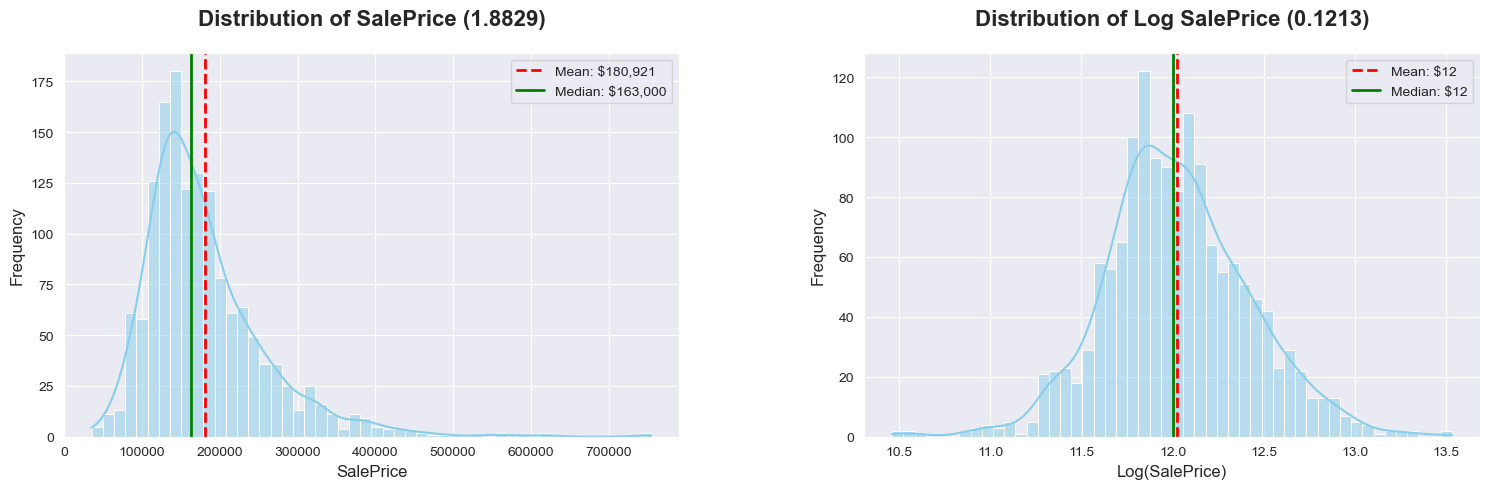

In [34]:
# Calculate statistics
y = train_org['SalePrice']
mean_price = y.mean()
median_price = y.median()

log_y = np.log1p(y)

(f"""Skewness : {y.skew():.4f}
Kurtosis : {y.kurtosis():.4f}""") # kurtosis > 3 means heavy tails, more outliers than normal.

# Plot histogram with KDE
fig, ax = plt.subplots(1, 2, figsize=(15,5))
sns.histplot(y, kde=True, bins=50, color='skyblue', ax=ax[0])

# Add mean and median lines
ax[0].axvline(mean_price, color="red", linestyle="--", linewidth=2, label=f"Mean: ${mean_price:,.0f}")
ax[0].axvline(median_price, color="green", linestyle="-", linewidth=2, label=f"Median: ${median_price:,.0f}")

# Labels and legend
fig.subplots_adjust(bottom=0.2)
ax[0].set_title(f"Distribution of SalePrice ({y.skew():.4f})", fontsize=16, fontweight='bold', pad=20)
ax[0].set_xlabel("SalePrice", fontsize=12)
ax[0].set_ylabel("Frequency", fontsize=12)
ax[0].legend()


# boxplot of SalePrice for outliers
sns.histplot(log_y, kde=True, bins=50, color='skyblue', ax=ax[1])

# Add mean and median lines
ax[1].axvline(log_y.mean(), color="red", linestyle="--", linewidth=2, label=f"Mean: ${log_y.mean():,.0f}")
ax[1].axvline(log_y.median(), color="green", linestyle="-", linewidth=2, label=f"Median: ${log_y.median():,.0f}")

# Labels and legend
fig.subplots_adjust(bottom=0.2)
ax[1].set_title(f"Distribution of Log SalePrice ({log_y.skew():.4f})", fontsize=16, fontweight='bold', pad=20)
ax[1].set_xlabel("Log(SalePrice)", fontsize=12)
ax[1].set_ylabel("Frequency", fontsize=12)
ax[1].legend()

plt.tight_layout()
plt.subplots_adjust(wspace=0.3, hspace=0.3)
plt.show()

- The distribution of `SalePrice` is right-skewed. So, we can consider transformation to reduce skewness before modeling.
- Sale prices range form USD 34,900 to USD 755,000.
- And this is `SalePrice` after log transformation. The sknewness has been fixed.


False

##### **2.2. Missing Values**

Most machine learning algorithms cannot be trained directly on datasets containing missing values. That's why it's crucial to detect them first and then decide whether to drop the affected features or impute the missing entries.

In [36]:
train_org.stb.missing().query("percent > 0")
# Crietria : Drop features with above 6% missing values.

,missing,total,percent
PoolQC,1453,1460,99.520548
MiscFeature,1406,1460,96.301370
Alley,1369,1460,93.767123
Fence,1179,1460,80.753425
MasVnrType,872,1460,59.726027
FireplaceQu,690,1460,47.260274
LotFrontage,259,1460,17.739726
GarageYrBlt,81,1460,5.547945
GarageCond,81,1460,5.547945
GarageType,81,1460,5.547945


In [52]:
# Checking if missing values affect sale price
from scipy import stats
def missing_value_impact(feature):
    if train_org[feature].isnull().sum() > 0:
        # Get values for homes with and without the features
        has_feature_prices = train_org[~train_org[feature].isnull()]['SalePrice']
        missing_feature_prices = train_org[train_org[feature].isnull()]['SalePrice']

        # Calculate means
        has_feature_mean = has_feature_prices.mean()
        missing_feature_mean = missing_feature_prices.mean()
        
        print(f'{feature}')
        print(f'  Average price with feature: ${has_feature_mean:.2f}')
        print(f'  Average price without feature: ${missing_feature_mean:.2f}')
        print(f'  Difference: ${has_feature_mean - missing_feature_mean:.2f}')
        print(f"  Count with feature: {len(has_feature_prices)}")
        print(f"  Count without feature: {len(missing_feature_prices)}")
        
        # Only run T-test if we have enough data in both groups
        if len(has_feature_prices) > 1 and len(missing_feature_prices) > 1:
            # Run the T-test
            t_stat, p_value = stats.ttest_ind(
                has_feature_prices,
                missing_feature_prices,
                equal_var=False  # Welch's t-test doesn't assume equal variance
            )
            print(f"  T-test: t-statistic = {t_stat:.2f}, p-value = {p_value:.6f}")
        else:
            print("  T-test: Not enough data in both groups for statistical comparison")


# Check for a few features with missing values
for feature in ['LotFrontage', 'BsmtQual', 'Electrical']:
    if train_org[feature].isnull().sum() > 0:
        missing_value_impact(feature)
        print("\n")

LotFrontage
  Average price with feature: $180770.48
  Average price without feature: $181620.07
  Difference: $-849.59
  Count with feature: 1201
  Count without feature: 259
  T-test: t-statistic = -0.20, p-value = 0.844353


BsmtQual
  Average price with feature: $182878.28
  Average price without feature: $105652.89
  Difference: $77225.39
  Count with feature: 1423
  Count without feature: 37
  T-test: t-statistic = 14.70, p-value = 0.000000


Electrical
  Average price with feature: $180930.39
  Average price without feature: $167500.00
  Difference: $13430.39
  Count with feature: 1459
  Count without feature: 1
  T-test: Not enough data in both groups for statistical comparison




#### **Impute Missing Values**
There are 34 features that have missing values. Will divide them into three groups based on the data description and percentage:

- **Group 1 - Categorical variables where NA means no feature:** 
PoolQC, MiscFeature, Alley, Fence, FireplaceQu, GarageType, GarageFinish, GarageQual, GarageCond, BsmtQual, BsmtCond, BsmtExposure, BsmtFinType1, BsmtFinType2, MasVnrType (15 variables)

    For group1, will impute `NA` with `None`.

- **Group 2 - Numerical variables where NA means no feature:**
GarageArea, GarageCars, BsmtFinSF1, BsmtFinSF2, BsmtUnfSF, TotalBsmtSF, BsmtFullBath, BsmtHalfBath, MasVnrArea, GarageYrBlt (9 variables)

    For group2, will impute `NA` with 0.

- **Group 3 - Other variables:** 
Functional, MSZoning, Electrical, KitchenQual, Exterior1st, Exterior2nd, SaleType, Utilities, LotFrontage, GarageYrBlt (10 variables)

    -  will impute Functional, MSZoning, Electrical, KitchenQual, Exterior1st, Exterior2nd, SaleType, Utilities with their modes,
    - impute LotFrontage with median by neighborhood.
    - impute GarageYrBlt with YearBuilt.



In [ ]:
from sklearn.impute import SimpleImputer

# Group 1:
group_1 = [
    'PoolQC', 'MiscFeature', 'Alley', 'Fence', 'FireplaceQu', 'GarageType',
    'GarageFinish', 'GarageQual', 'GarageCond', 'BsmtQual', 'BsmtCond',
    'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'MasVnrType'
]
train_org[group_1] = train_org[group_1].fillna("None")

# Group 2:
group_2 = [
    'GarageArea', 'GarageCars', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF',
    'TotalBsmtSF', 'BsmtFullBath', 'BsmtHalfBath', 'MasVnrArea'
]

train_org[group_2] = train_org[group_2].fillna(0)

# Group 3:
group_3a = [
    'Functional', 'MSZoning', 'Electrical', 'KitchenQual', 'Exterior1st',
    'Exterior2nd', 'SaleType', 'Utilities'
]

imputer = SimpleImputer(strategy='most_frequent')
train_org[group_3a] = pd.DataFrame(imputer.fit_transform(train_org[group_3a]), index=train_org.index)

train_org['LotFrontage'] = train_org.groupby('Neighborhood')['LotFrontage'].transform(lambda x: x.fillna(x.median()))
train_org.loc[train_org['GarageYrBlt'].isnull(), 'GarageYrBlt'] = train_org.loc[train_org['GarageYrBlt'].isnull(), 'YearBuilt']


##### **2.3. Outliers Treatment**

Because regression models are very sensitive to outlier, we need to be aware of them. Let's examine outliers with a scatter plot.



In [51]:
"""
Calculate the percentage of outliers based on winsorization method for all the numerical features in the DataFrame.

Parameters:
df(pd.DataFrame): The input DataFrame containing numerical features.
lower_percentile(float): The lower percentile foe winsorization. Default is 5.
upper_percentile(float): The upper percentile for winsorization. Default is 95.

Returns:
pd.DataFrame : A DataFrame containing the columns name and percentage of outliers for each numerical features.
"""

#numeric_df = df_train[df_train.columns.difference(['SalePrice'])]
numeric_cols = train_org.select_dtypes(include='number').columns.difference(['SalePrice', 'Id', 'YearBuilt', 'YearRemodAdd', 'GarageYrBlt', 'YrSold'])
numeric_df = train_org[numeric_cols]
outliers_percentages = {}
for col in numeric_df.columns:
    x_low, x_high = np.percentile(numeric_df[col].dropna(),[1,99])
    total_values = len(numeric_df[col])
    outliers = len(numeric_df[~numeric_df[col].between(x_low,x_high)])
    outliers_percentage = round((outliers / total_values)*100 , 2)
    outliers_percentages[col] = outliers_percentage
    
outliers_df = pd.DataFrame(list(outliers_percentages.items()), columns=['Features','Outliers Percentage'])
outliers_data = outliers_df.sort_values(by='Outliers Percentage', ascending=False).reset_index(drop=True)
outliers_data.head()


,Features,Outliers Percentage
0,LotFrontage,18.56
1,GrLivArea,2.05
2,1stFlrSF,1.85
3,MasVnrArea,1.58
4,LotArea,1.51


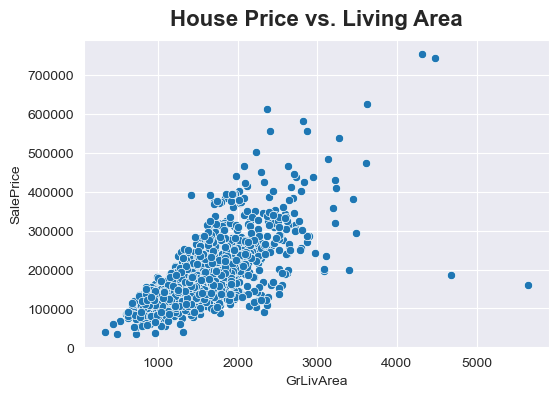

In [53]:
fig, ax = plt.subplots(figsize=(6, 4))
sns.scatterplot(x='GrLivArea', y='SalePrice', data=train_org, ax=ax)
ax.set_title('House Price vs. Living Area', fontsize=16, fontweight='bold', y=1.02)
plt.show()

There are two observations lying separately from the rest. They have large living area but low price. They are the outliers that we are looking for. Will delete them from the training set.

In [55]:
display_md("**Outliers Treatment**")
outlier_index = train_org[(train_org.GrLivArea > 4000)
                           & (train_org.SalePrice < 200000)].index
train_org.drop(outlier_index, axis="index", inplace=True)
y.drop(outlier_index, axis="index", inplace=True)

**Outliers Treatment**